# Module 0 — Foundations & number formats

> Quantization course for **agentic post-training AI engineer** interviews.
> Source of truth: [../../guide.md](../../guide.md). Runs on the Windows `.venv` (RTX 5090).

**Learning objectives** — after this notebook you can:
1. Derive and implement the affine quantization map end-to-end.
2. Explain symmetric vs asymmetric, and per-tensor / per-channel / per-group granularity, and *show* why per-group wins.
3. Compare FP32 / FP16 / BF16 / FP8 / INT8 / INT4 / NF4 and say when each is used.
4. Distinguish PTQ vs QAT and static vs dynamic calibration.
5. Reason about the **memory-bound vs compute-bound** axis and the W4A16 / W8A8 / FP8 deployment choice.

**Prerequisites:** basic linear algebra, PyTorch tensors. No GPU strictly required (uses CUDA if present).

**Why it matters in interviews:** almost every quantization question builds on these primitives. You will be asked to whiteboard the affine map, justify per-group scaling, and explain *why activations are harder to quantize than weights* (systematic outlier channels — Module 3).

## 0.1 Why quantize? Memory-bound vs compute-bound

Quantization maps high-precision values (FP32/FP16/BF16) onto a smaller set of low-precision
values to cut **memory**, **memory bandwidth**, and — when activations are also quantized —
**compute**.

Two regimes drive every design choice:
- **Memory/bandwidth-bound** (single-stream decoding, local inference): you are limited by
  reading weights from HBM each step. **Weight-only** quant (e.g. W4A16) wins — 4-bit weights
  mean ~4x less to move.
- **Compute-bound** (large-batch / high-throughput serving): you are limited by matmul FLOPs.
  **Weight+activation** quant (W8A8 INT8 or FP8) wins because the matmuls themselves run in
  low precision.

The cell below makes the memory side concrete.

In [1]:
import platform
from pathlib import Path
import numpy as np
import torch

torch.manual_seed(0)
np.random.seed(0)

def find_root(markers=('LLM_model_weights', '.venv', 'requirements.txt')):
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if any((cand / m).exists() for m in markers):
            return cand
    return here

ROOT = find_root()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Python {platform.python_version()} | torch {torch.__version__} | CUDA build {torch.version.cuda} | device={DEVICE}')
if DEVICE == 'cuda':
    print('GPU :', torch.cuda.get_device_name(0))
print('root:', ROOT)

def model_bytes(num_params, bits):
    return num_params * bits / 8

print('\nApprox weight memory (GB) by bit-width:')
print(f"{'model':14s}{'bf16':>8s}{'int8':>8s}{'int4':>8s}")
for name, p in [('Qwen3-1.7B', 1.7e9), ('Qwen3-14B', 14.8e9), ('Llama-70B', 70e9)]:
    row = ''.join(f'{model_bytes(p, b)/1e9:8.1f}' for b in (16, 8, 4))
    print(f'{name:14s}{row}')

Python 3.12.13 | torch 2.11.0+cu128 | CUDA build 12.8 | device=cuda
GPU : NVIDIA GeForce RTX 5090
root: F:\agent_learning

Approx weight memory (GB) by bit-width:
model             bf16    int8    int4
Qwen3-1.7B         3.4     1.7     0.8
Qwen3-14B         29.6    14.8     7.4
Llama-70B        140.0    70.0    35.0


## 0.2 The affine map

The canonical (affine / uniform) quantizer maps a real value $x$ to an integer code $x_q$:

$$x_q = \mathrm{clamp}\!\left(\mathrm{round}\!\left(\tfrac{x}{s}\right) + z,\; q_{min},\; q_{max}\right), \qquad x \approx s\,(x_q - z)$$

- **scale** $s$ sets the step size; **zero-point** $z$ is the integer that represents real 0.
- **Symmetric:** $z = 0$, $s = \dfrac{\max(|x|)}{q_{max}}$ — one number, hardware-friendly, standard for **weights**.
- **Asymmetric:** $z \neq 0$, $s = \dfrac{x_{max}-x_{min}}{q_{max}-q_{min}}$ — handles skewed/one-sided ranges (e.g. post-ReLU **activations**).

For INT$b$: symmetric uses $[-2^{b-1}, 2^{b-1}-1]$, asymmetric uses $[0, 2^{b}-1]$.

In [2]:
def quantize_affine(x, num_bits=8, symmetric=False, axis=None):
    # Affine-quantize x -> (q, scale, zero). Per-tensor if axis is None,
    # else one scale per slice along `axis` (keep-dim).
    if symmetric:
        qmin, qmax = -(2 ** (num_bits - 1)), 2 ** (num_bits - 1) - 1
    else:
        qmin, qmax = 0, 2 ** num_bits - 1
    if axis is None:
        mn, mx = x.min(), x.max()
    else:
        mn = x.amin(dim=axis, keepdim=True)
        mx = x.amax(dim=axis, keepdim=True)
    if symmetric:
        scale = torch.clamp(torch.maximum(mx.abs(), mn.abs()) / qmax, min=1e-12)
        zero = torch.zeros_like(scale)
    else:
        scale = torch.clamp((mx - mn) / (qmax - qmin), min=1e-12)
        zero = torch.round(qmin - mn / scale)
    q = torch.clamp(torch.round(x / scale) + zero, qmin, qmax)
    return q, scale, zero

def dequantize_affine(q, scale, zero):
    return (q - zero) * scale

def qmse(x, **kw):
    q, s, z = quantize_affine(x, **kw)
    return torch.mean((x - dequantize_affine(q, s, z)) ** 2).item()

x = torch.tensor([-0.9, -0.3, 0.0, 0.2, 0.8, 1.7])
q, s, z = quantize_affine(x, num_bits=4, symmetric=False)
print('x        :', x.tolist())
print('q (int)  :', q.int().tolist(), '| scale=%.4f zero=%.0f' % (s.item(), z.item()))
print('dequant  :', [round(v, 3) for v in dequantize_affine(q, s, z).tolist()])
print('INT4 MSE :', round(qmse(x, num_bits=4, symmetric=False), 6))

x        : [-0.8999999761581421, -0.30000001192092896, 0.0, 0.20000000298023224, 0.800000011920929, 1.7000000476837158]
q (int)  : [0, 3, 5, 6, 10, 15] | scale=0.1733 zero=5
dequant  : [-0.867, -0.347, 0.0, 0.173, 0.867, 1.733]
INT4 MSE : 0.001593


## 0.3 Symmetric vs asymmetric

Asymmetric pays for an extra zero-point but uses the *whole* code range on skewed data.
On a **one-sided** distribution (like post-ReLU activations) symmetric wastes half its codes
on never-used negatives; on **zero-centered** data (like weights) the two are about equal — so
weights typically use cheaper symmetric quantization.

In [3]:
relu_like = torch.relu(torch.randn(20000))   # one-sided, like a post-activation
print('one-sided data  (min=%.2f, max=%.2f):' % (relu_like.min(), relu_like.max()))
print('  INT8 asymmetric MSE:', f'{qmse(relu_like, num_bits=8, symmetric=False):.3e}')
print('  INT8 symmetric  MSE:', f'{qmse(relu_like, num_bits=8, symmetric=True):.3e}')

sym_data = torch.randn(20000)                 # zero-centered, like weights
print('zero-centered data:')
print('  INT8 asymmetric MSE:', f'{qmse(sym_data, num_bits=8, symmetric=False):.3e}')
print('  INT8 symmetric  MSE:', f'{qmse(sym_data, num_bits=8, symmetric=True):.3e}')

one-sided data  (min=0.00, max=4.10):
  INT8 asymmetric MSE: 1.039e-05
  INT8 symmetric  MSE: 4.306e-05
zero-centered data:
  INT8 asymmetric MSE: 9.051e-05
  INT8 symmetric  MSE: 1.072e-04


## 0.4 Granularity: per-tensor → per-channel → per-group

One scale for a whole tensor is cheap but a single outlier sets a coarse step for *everything*.
Finer granularity contains outlier damage at the cost of storing more scales:

- **per-tensor** — 1 scale (worst accuracy)
- **per-channel / per-row** — 1 scale per output row
- **per-group** — 1 scale per block of e.g. 128 weights along the input dim (**the 4-bit standard**)

Below, two input channels are blown up into outliers. Watch per-group isolate them.

INT4 per-tensor    : MSE = 1.0485e+00
INT4 per-row       : MSE = 6.2573e-01
INT4 per-group-128 : MSE = 2.1382e-01
INT4 per-group-64  : MSE = 1.1111e-01


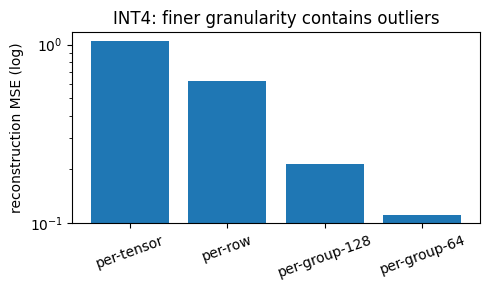

In [4]:
import matplotlib.pyplot as plt

torch.manual_seed(0)
W = torch.randn(512, 512)
W[:, 7]   *= 25.0    # outlier input channels (present in EVERY row)
W[:, 200] *= 18.0

def per_group_mse(W, bits=4, group=128, symmetric=True):
    out, inn = W.shape
    Wq = torch.empty_like(W)
    for s in range(0, inn, group):
        blk = W[:, s:s + group]
        q, sc, z = quantize_affine(blk, num_bits=bits, symmetric=symmetric, axis=1)
        Wq[:, s:s + group] = dequantize_affine(q, sc, z)
    return torch.mean((W - Wq) ** 2).item()

results = {
    'per-tensor':    qmse(W, num_bits=4, symmetric=True),
    'per-row':       per_group_mse(W, bits=4, group=W.shape[1]),
    'per-group-128': per_group_mse(W, bits=4, group=128),
    'per-group-64':  per_group_mse(W, bits=4, group=64),
}
for k, v in results.items():
    print(f'INT4 {k:14s}: MSE = {v:.4e}')

plt.figure(figsize=(5, 3))
plt.bar(list(results.keys()), list(results.values()))
plt.yscale('log'); plt.ylabel('reconstruction MSE (log)')
plt.title('INT4: finer granularity contains outliers')
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 0.5 Number formats

| format | bits | what it buys |
|--------|-----:|--------------|
| FP32 | 32 | reference precision |
| FP16 | 16 | 5 exp / 10 mantissa — **small dynamic range** (overflows ~65504) |
| **BF16** | 16 | 8 exp / 7 mantissa — **FP32 range**, less precision -> default for training/serving |
| FP8 E4M3 | 8 | 4 exp / 3 mantissa — more precision, used for weights/activations (fwd) |
| FP8 E5M2 | 8 | 5 exp / 2 mantissa — more range, used for gradients (bwd) |
| INT8 | 8 | W8A8 near-lossless |
| INT4 | 4 | weight-only sweet spot (W4A16) |
| **NF4** | 4 | non-uniform quantile grid, information-optimal for Gaussian weights (QLoRA) |

The cells below *demonstrate* the three most interview-relevant facts: BF16's range,
FP8's two encodings (native on this Blackwell GPU), and NF4's non-uniform grid.

In [5]:
# (a) BF16 vs FP16 dynamic range
big = torch.tensor(70000.0)
print('value 70000 ->  fp16:', big.half().item(), '|  bf16:', big.bfloat16().item())
print('fp16 max =', torch.finfo(torch.float16).max, '| bf16 max =', torch.finfo(torch.bfloat16).max)
print('=> FP16 overflows to inf; BF16 keeps FP32 range. That is why training uses BF16.\n')

# (b) FP8 on Blackwell (native); degrades gracefully elsewhere
try:
    v = torch.randn(6)
    e4m3 = v.to(torch.float8_e4m3fn).float()
    e5m2 = v.to(torch.float8_e5m2).float()
    print('original:', [round(t, 3) for t in v.tolist()])
    print('e4m3    :', [round(t, 3) for t in e4m3.tolist()], '| max %.0f (precision)' % torch.finfo(torch.float8_e4m3fn).max)
    print('e5m2    :', [round(t, 3) for t in e5m2.tolist()], '| max %.0f (range)' % torch.finfo(torch.float8_e5m2).max)
except Exception as e:
    print('fp8 cast unavailable here:', repr(e))

value 70000 ->  fp16: inf |  bf16: 70144.0
fp16 max = 65504.0 | bf16 max = 3.3895313892515355e+38
=> FP16 overflows to inf; BF16 keeps FP32 range. That is why training uses BF16.

original: [-0.59, 1.283, -0.509, -0.744, 0.244, 1.4]
e4m3    : [-0.562, 1.25, -0.5, -0.75, 0.25, 1.375] | max 448 (precision)
e5m2    : [-0.625, 1.25, -0.5, -0.75, 0.25, 1.5] | max 57344 (range)


NF4  : [-1.   -0.71 -0.54 -0.42 -0.31 -0.22 -0.13 -0.04  0.04  0.13  0.22  0.31
  0.42  0.54  0.71  1.  ]
INT4 : [-1.   -0.87 -0.73 -0.6  -0.47 -0.33 -0.2  -0.07  0.07  0.2   0.33  0.47
  0.6   0.73  0.87  1.  ] (uniform)


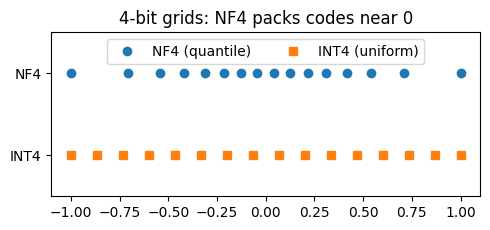

In [6]:
# (c) NF4: 16 levels at Gaussian quantiles -> codes cluster where weight mass is
from scipy.stats import norm
ks = (np.arange(16) + 0.5) / 16
nf4 = norm.ppf(ks); nf4 = nf4 / np.abs(nf4).max()
int4 = np.linspace(-1, 1, 16)
print('NF4  :', np.round(nf4, 2))
print('INT4 :', np.round(int4, 2), '(uniform)')

plt.figure(figsize=(5, 2.4))
plt.plot(nf4, [1]*16, 'o', label='NF4 (quantile)')
plt.plot(int4, [0]*16, 's', label='INT4 (uniform)')
plt.yticks([0, 1], ['INT4', 'NF4']); plt.ylim(-0.5, 1.5)
plt.legend(loc='upper center', ncol=2); plt.title('4-bit grids: NF4 packs codes near 0')
plt.tight_layout(); plt.show()

## 0.6 PTQ vs QAT, and static vs dynamic calibration

- **PTQ** (post-training quant): quantize a trained model with little/no retraining
  (GPTQ, AWQ, SmoothQuant — minutes to hours). **Default for LLMs** because retraining is costly.
- **QAT** (quantization-aware training): simulate quantization during training with a
  straight-through estimator so weights adapt (BitNet, gpt-oss FP4 recovery). Best at
  sub-4-bit, but expensive.

**Calibration** runs a small representative batch to set scales. **Static** freezes scales
offline; **dynamic** recomputes them per token/batch at runtime — more accurate for
activations, and the reason FP8 W8A8 is "effectively lossless".

In [7]:
calib = torch.randn(128, 256)                   # calibration batch (well-behaved)
scale_static = calib.abs().max() / 127.0        # frozen at calibration time

def aq_static(a):
    return torch.clamp(torch.round(a / scale_static), -127, 127) * scale_static

def aq_dynamic(a):
    s = a.abs().max() / 127.0                    # recomputed per batch at runtime
    return torch.clamp(torch.round(a / s), -127, 127) * s

runtime = torch.randn(8, 256) * 1.8 + 0.5        # distribution shift at inference time
print('activation INT8 under a runtime distribution shift:')
print('  static  scale MSE:', f'{torch.mean((runtime - aq_static(runtime))**2).item():.3e}')
print('  dynamic scale MSE:', f'{torch.mean((runtime - aq_dynamic(runtime))**2).item():.3e}')
print('=> dynamic scales track activation ranges; static scales clip the shifted values.')

activation INT8 under a runtime distribution shift:
  static  scale MSE: 8.082e-03
  dynamic scale MSE: 2.276e-04
=> dynamic scales track activation ranges; static scales clip the shifted values.


## 0.7 The deployment decision: W4A16 vs W8A8 vs FP8

| scheme | what is low-precision | wins when | note |
|--------|-----------------------|-----------|------|
| **W4A16** | 4-bit weights, 16-bit acts | memory-bound, sync / single-stream decode | most cost-efficient for synchronous serving |
| **W8A8 (INT8)** | 8-bit weights + acts | compute-bound, async continuous batching | ~1–3% accuracy drop when well-tuned |
| **W8A8 (FP8)** | FP8 weights + acts | compute-bound on Hopper/Blackwell | effectively lossless across scales |

(Red Hat / Neural Magic, 500k+ evals, arXiv:2411.02355: "FP8 is effectively lossless …
W4A16 is the most cost-efficient for synchronous setups, while W8A8 dominates in
asynchronous continuous batching.")

Now let's quantize a **real** weight tensor from Qwen3-1.7B and confirm per-group beats
per-tensor on actual weights.

loaded model.layers.0.mlp.down_proj.weight  shape=(2048, 6144)
  INT4 per-tensor   MSE: 5.9939e-04
  INT4 per-group-128 MSE: 1.6820e-05


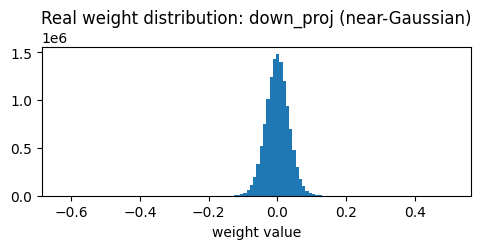

In [8]:
qwen = ROOT / 'LLM_model_weights' / 'Qwen3-1.7B'
try:
    from safetensors import safe_open
    shard = sorted(qwen.glob('*.safetensors'))[0]
    with safe_open(str(shard), framework='pt', device='cpu') as f:
        key = next(k for k in f.keys() if k.endswith('proj.weight'))
        Wr = f.get_tensor(key).float()
    print(f'loaded {key}  shape={tuple(Wr.shape)}')
    print('  INT4 per-tensor   MSE:', f'{qmse(Wr, num_bits=4, symmetric=True):.4e}')
    print('  INT4 per-group-128 MSE:', f'{per_group_mse(Wr, bits=4, group=128):.4e}')
    flat = Wr.flatten().numpy()
    plt.figure(figsize=(5, 2.6))
    plt.hist(flat, bins=120)
    plt.title(f'Real weight distribution: {key.split(".")[-2]} (near-Gaussian)')
    plt.xlabel('weight value'); plt.tight_layout(); plt.show()
except Exception as e:
    print('Skipping real-weight peek (model not found / unreadable):', repr(e))
    print('The from-scratch results above stand on their own.')

## Interview drill

1. **Write the affine quant + dequant equations.** Define scale and zero-point. When is the zero-point 0?
2. **Why does per-group beat per-tensor?** Because a single outlier sets one coarse step for the whole tensor; per-group confines an outlier's coarse step to its block. (We measured ~orders-of-magnitude lower MSE.)
3. **Why BF16 over FP16 for training?** Same 8 exponent bits as FP32 → same dynamic range → no loss-scaling/overflow; you trade mantissa precision you don't need.
4. **Why are activations harder to quantize than weights?** Weights are static and near-Gaussian; activations have *systematic outlier channels* that appear at scale (Module 3) and shift at runtime → need dynamic / per-channel handling.
5. **Symmetric vs asymmetric — when each?** Symmetric for zero-centered weights (cheaper, no zero-point); asymmetric for skewed/one-sided activations.
6. **Static vs dynamic calibration?** Static freezes scales offline (fast, can clip under shift); dynamic recomputes per token/batch (accurate, what makes FP8 W8A8 ~lossless).
7. **PTQ vs QAT — default and why?** PTQ is default for LLMs (retraining is costly); QAT is reserved for sub-4-bit or when PTQ accuracy is insufficient.
8. **W4A16 vs W8A8 — which for what?** W4A16 for memory-bound single-stream decode; W8A8 for compute-bound high-throughput batched serving.

## Depth story — "Why are activations the whole game?"

The arc of the entire field is *fighting activation outliers*: keep them in higher precision
(LLM.int8()), migrate them into weights (SmoothQuant), protect salient channels (AWQ), or
rotate them away (QuaRot/SpinQuant). Foundations matter because every one of those methods is
just a smarter answer to "a few activation dimensions have huge dynamic range, and a single
shared scale can't serve both them and everything else." Keep that sentence ready — it frames
Modules 1–7.

---
**Next:** [`01_gptq.ipynb`](01_gptq.ipynb) — GPTQ: Hessian-based, error-compensating weight quantization.